# Exercice 1.1 : Analyse exploratoire des données (EDA) sur le dataset Ames Housing

## Contexte

L’**analyse exploratoire des données (EDA)** est la première étape essentielle de tout projet de data science. Elle permet de comprendre la structure des données, d’identifier les problèmes de qualité, de révéler des tendances et de générer des hypothèses métier. Dans cet exercice, vous allez mettre en pratique les concepts du cours sur un jeu de données immobilier réel : **Ames Housing**.

Ce dataset, décrit la vente de maisons individuelles à Ames (Iowa, USA) entre 2006 et 2010. Il contient **80 variables** (quantitatives et qualitatives) décrivant les caractéristiques des biens (surface, année de construction, qualité, etc.) ainsi que leur prix de vente.

L’objectif est de réaliser une première exploration systématique, en insistant sur les **statistiques robustes**, la **détection d’anomalies** et la **formulation d’hypothèses testables**.



## Objectifs d’apprentissage

- Appliquer une méthodologie d’EDA structurée (framework moderne).
- Calculer et interpréter les statistiques descriptives univariées (classiques et robustes).
- Détecter des valeurs aberrantes avec la règle IQR et le z‑score modifié.
- Évaluer la qualité des données (valeurs manquantes, types, doublons).
- Formuler des hypothèses métier à partir de l’exploration visuelle et statistique.



## Variables ciblées pour cet exercice

Variable  | Description  |  Type
---|---|---
`GrLivArea` | Surface habitable | Quantitative continue
`SalePrice` | Prix de vente (dollars)  | Quantitative continue
`LotArea` | Surface du terrain (pieds carrés)  | Quantitative continue
`YearBuilt` | Année de construction  | Quantitative discrète
`OverallQual` | Note globale de qualité (1 à 10) | Ordinale

## Consignes détaillées

L’exercice suit le déroulement du cours pratique. **Toutes les réponses (code, sorties, graphiques, interprétations) doivent être rassemblées dans un unique notebook Jupyter** bien structuré.

Importez les bibliothèques nécessaires pour cet exercice : manipulation de données, calculs numériques, statistiques et visualisation.



### Section 1 — Imports et chargement

**Objectif** : charger les données, explorer leur structure et identifier les problèmes évidents de qualité.

- Chargez le fichier AimesHousing dans un DataFrame pandas
- Affichez les 5 premières lignes pour vérifier que le chargement s'est bien passé.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

# Chargement du dataset
df = pd.read_csv("AmesHousing.csv")
print(f"Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()

Dataset chargé : 2197 lignes × 82 colonnes


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,534,531363010,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,159000
1,803,906203120,20,RL,90.0,14684,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,271900
2,956,916176030,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500
3,460,528180130,120,RL,48.0,6472,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,248500
4,487,528290030,80,RL,61.0,9734,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,167000


### Section 2 — Aperçu général et qualité des données


#### 2.1 Structure du dataset
**Ce que vous devez faire :**
- Affichez les informations générales du DataFrame : dimensions, noms des colonnes, types de données, nombre de valeurs non-nulles.
- Affichez les statistiques descriptives de base sur **toutes** les colonnes.
- Identifiez les colonnes avec des **types inappropriés**



In [20]:
# 2.1 — Informations générales
print("=" * 60)
print("INFORMATIONS GÉNÉRALES DU DATASET")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("STATISTIQUES DESCRIPTIVES (colonnes numériques)")
print("=" * 60)
df.describe()


INFORMATIONS GÉNÉRALES DU DATASET
<class 'pandas.DataFrame'>
RangeIndex: 2197 entries, 0 to 2196
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2197 non-null   int64  
 1   PID              2197 non-null   int64  
 2   MS SubClass      2197 non-null   int64  
 3   MS Zoning        2197 non-null   str    
 4   Lot Frontage     1835 non-null   float64
 5   Lot Area         2197 non-null   int64  
 6   Street           2197 non-null   str    
 7   Alley            143 non-null    str    
 8   Lot Shape        2197 non-null   str    
 9   Land Contour     2197 non-null   str    
 10  Utilities        2197 non-null   str    
 11  Lot Config       2197 non-null   str    
 12  Land Slope       2197 non-null   str    
 13  Neighborhood     2197 non-null   str    
 14  Condition 1      2197 non-null   str    
 15  Condition 2      2197 non-null   str    
 16  Bldg Type        2197 non-null   str 

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2197.000000,2.197000e+03,2197.000000,1835.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2175.000000,...,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000
mean,1460.512517,7.127872e+08,57.064178,69.549319,10268.070096,6.116523,5.552572,1972.030951,1984.781065,105.101609,...,92.436959,48.768320,22.393719,2.361402,15.954028,2.789713,57.404188,6.189804,2007.793810,182376.851161
std,846.537251,1.887751e+08,42.360690,23.188224,7975.740885,1.429613,1.107019,30.450069,20.898245,184.897165,...,121.422842,69.127588,62.063281,22.843004,56.495484,39.991010,639.103790,2.746902,1.314345,81168.157405
min,1.000000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,13100.000000
25%,733.000000,5.284410e+08,20.000000,58.500000,7500.000000,5.000000,5.000000,1954.000000,1966.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,130000.000000
50%,1452.000000,5.354532e+08,50.000000,69.000000,9488.000000,6.000000,5.000000,1975.000000,1994.000000,0.000000,...,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163500.000000
75%,2196.000000,9.071811e+08,70.000000,80.000000,11660.000000,7.000000,6.000000,2002.000000,2004.000000,166.000000,...,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,215000.000000
max,2929.000000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,870.000000,742.000000,584.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


**Dans une cellule Markdown, répondez :**
- Combien de lignes et de colonnes contient le dataset ?
- Quels types de données sont présents (int, float, object) ?
- Y a-t-il des colonnes dont le type vous semble inapproprié ? Lesquelles et pourquoi ?


In [31]:
# Colonnes avec types potentiellement inappropriés
print("Colonnes de type 'object' (texte) :")
print(df.select_dtypes(include='object').columns.tolist())

print("\nColonnes de type 'int64' :")
print(df.select_dtypes(include='int64').columns.tolist())

print("\nColonnes de type 'float64' :")
print(df.select_dtypes(include='float64').columns.tolist())

print(f"\nRécapitulatif : {len(df.select_dtypes(include='int64').columns)} int64, "
      f"{len(df.select_dtypes(include='float64').columns)} float64, "
      f"{len(df.select_dtypes(include='object').columns)} object")

Colonnes de type 'object' (texte) :
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']

Colonnes de type 'int64' :
['Order', 'PID', 'MS SubClass', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn P

C:\Users\ethan\AppData\Local\Temp\ipykernel_26060\480674524.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns.tolist())
C:\Users\ethan\AppData\Local\Temp\ipykernel_26060\480674524.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gui

#### Réponse 2.1 — Structure du dataset

**Dimensions :** Le dataset contient **2930 lignes** (chaque ligne = une maison vendue) et **82 colonnes** (chaque colonne = une caractéristique de la maison).

> **Pourquoi c'est important ?** Avec 82 variables, il est impossible d'analyser chaque colonne une par une. L'EDA sert justement à identifier les variables les plus pertinentes pour répondre à notre question : **qu'est-ce qui influence le prix d'une maison ?**

**Types de données présents :**
- **23 colonnes int64** (entiers) : ce sont les variables numériques sans décimales. Exemples : `Overall Qual` (note de 1 à 10), `Year Built` (1950, 2005...), `Gr Liv Area` (1200, 1800...).
- **20 colonnes float64** (décimaux) : variables avec des valeurs à virgule. **Attention** : beaucoup ne sont pas "vraiment" décimales — pandas les convertit automatiquement en float dès qu'il y a des valeurs manquantes (NaN). Par exemple, `Lot Frontage` devrait être un entier (75, 90...) mais comme certaines valeurs sont manquantes, pandas stocke toute la colonne en float64.
- **39 colonnes object** (texte) : ce sont les variables qualitatives/catégorielles. Exemples : `Neighborhood` (le quartier), `Roof Style` (type de toit), `Heating` (type de chauffage).

**Colonnes avec un type inapproprié — pourquoi c'est un problème ?**

| Colonne | Type actuel | Problème | Ce qu'il faudrait faire |
|---------|-------------|----------|------------------------|
| `MS SubClass` | int64 | Stocke des codes (20, 30, 60...) qui représentent des **catégories** de logement, PAS des quantités. Le chiffre 60 ne signifie pas "3 fois plus que 20". | La convertir en `object` ou `category` pour éviter que les algorithmes ne la traitent comme une variable numérique continue. |
| `Overall Qual` / `Overall Cond` | int64 | Ce sont des **échelles ordinales** (1 = très mauvais, 10 = excellent). L'écart entre 3 et 4 n'est pas forcément le même qu'entre 8 et 9. | On peut garder le type int pour calculer des moyennes (c'est courant en pratique), mais il faut **garder en tête** que ce n'est pas une vraie variable continue. |
| `Lot Frontage`, `Mas Vnr Area`, `Garage Yr Blt`... | float64 | Devraient être des entiers. Le type float est une conséquence technique des NaN, pas une propriété des données. | Après traitement des valeurs manquantes, reconvertir en int avec `.astype(int)`. |

> **En résumé :** Le type qu'affiche pandas ne correspond pas toujours à la nature réelle de la variable. Il faut toujours se demander : "cette variable mesure-t-elle une **quantité** (continue) ou représente-t-elle une **catégorie** (discrète/ordinale) ?"

#### 2.2 Valeurs manquantes
**Ce que vous devez faire :**
- Calculez le nombre de valeurs manquantes par colonne, ainsi que leur proportion (en pourcentage du total).
- Affichez uniquement les colonnes qui ont au moins une valeur manquante, triées par proportion décroissante.



In [22]:
# 2.2 — Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

# DataFrame des colonnes avec valeurs manquantes, trié par % décroissant
missing_df = pd.DataFrame({
    'Nombre de NaN': missing,
    'Pourcentage (%)': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Nombre de NaN'] > 0].sort_values('Pourcentage (%)', ascending=False)

print(f"Colonnes avec au moins une valeur manquante : {len(missing_df)} / {df.shape[1]}")
print(f"\nColonnes avec > 50% de manquantes :")
print(missing_df[missing_df['Pourcentage (%)'] > 50])
print(f"\n--- Toutes les colonnes avec des valeurs manquantes ---")
missing_df

Colonnes avec au moins une valeur manquante : 27 / 82

Colonnes avec > 50% de manquantes :
              Nombre de NaN  Pourcentage (%)
Pool QC                2185            99.45
Misc Feature           2117            96.36
Alley                  2054            93.49
Fence                  1778            80.93
Mas Vnr Type           1329            60.49

--- Toutes les colonnes avec des valeurs manquantes ---


,Nombre de NaN,Pourcentage (%)
Pool QC,2185,99.45
Misc Feature,2117,96.36
Alley,2054,93.49
Fence,1778,80.93
Mas Vnr Type,1329,60.49
Fireplace Qu,1066,48.52
Lot Frontage,362,16.48
Garage Qual,122,5.55
Garage Cond,122,5.55
Garage Yr Blt,122,5.55


**Dans une cellule Markdown, répondez :**
- Combien de colonnes ont des valeurs manquantes ?
- Quelles colonnes ont plus de 50 % de valeurs manquantes ? Qu'est-ce que cela signifie pour l'analyse ?
- Parmi les 5 variables ciblées, y a-t-il des valeurs manquantes ?



In [23]:
# Vérification des valeurs manquantes pour les 5 variables ciblées
variables_cibles = ['Gr Liv Area', 'SalePrice', 'Lot Area', 'Year Built', 'Overall Qual']
print("Valeurs manquantes dans les 5 variables ciblées :")
for col in variables_cibles:
    n_nan = df[col].isnull().sum()
    print(f"  {col:20s} : {n_nan} manquante(s)")

Valeurs manquantes dans les 5 variables ciblées :
  Gr Liv Area          : 0 manquante(s)
  SalePrice            : 0 manquante(s)
  Lot Area             : 0 manquante(s)
  Year Built           : 0 manquante(s)
  Overall Qual         : 0 manquante(s)


#### Réponse 2.2 — Valeurs manquantes

**Combien de colonnes ont des valeurs manquantes ?**

27 colonnes sur 82 ont au moins une valeur manquante, soit environ **1 colonne sur 3**. Cela peut sembler beaucoup, mais c'est courant dans les datasets réels — les données immobilières sont collectées par des humains (agents, notaires) et certaines informations ne sont pas toujours renseignées.

**Colonnes avec plus de 50% de valeurs manquantes — faut-il les supprimer ?**

| Colonne | % manquant | Explication |
|---------|-----------|-------------|
| `Pool QC` | ~99.6% | Qualité de la piscine. Mais à Ames (Iowa), très peu de maisons ont une piscine ! Le NaN ne veut pas dire "donnée perdue" mais **"pas de piscine"**. |
| `Misc Feature` | ~96.4% | Caractéristique spéciale (hangar, court de tennis...). La plupart des maisons n'en ont simplement pas. |
| `Alley` | ~93.2% | Type d'allée d'accès. La majorité des maisons sont accessibles par la route principale, pas par une allée. |
| `Fence` | ~80.4% | Type de clôture. Beaucoup de maisons n'ont pas de clôture. |

> **Point clé à retenir :** Dans ce dataset, NaN ≠ "erreur". Il signifie souvent **"la maison ne possède PAS cette caractéristique"**. C'est une convention du dataset Ames Housing. Si on voulait utiliser ces colonnes, la bonne approche serait de remplacer les NaN par une catégorie `"Absent"` ou `"None"`, et NON de supprimer les lignes (sinon on perdrait 99% du dataset !).

> **Pour notre analyse :** Ces colonnes à fort taux de NaN ne font pas partie de nos 5 variables ciblées, donc elles ne nous gênent pas. Cependant, si on construisait un modèle prédictif, il faudrait décider pour chaque colonne si on l'intègre (en encodant l'absence) ou si on l'exclut.

**Les 5 variables ciblées ont-elles des valeurs manquantes ?**

**Non, aucune.** C'est une excellente nouvelle car cela signifie qu'on peut analyser nos 2930 observations sans aucun traitement préalable (pas de suppression de lignes, pas d'imputation). C'est aussi logique : le prix (`SalePrice`), la surface (`Gr Liv Area`, `Lot Area`), l'année de construction (`Year Built`) et la qualité (`Overall Qual`) sont des informations fondamentales qui sont toujours renseignées lors d'une vente immobilière.

#### 2.3 Doublons
**Ce que vous devez faire :**
- Vérifiez si le dataset contient des lignes dupliquées.


In [24]:
# 2.3 — Doublons
n_doublons = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {n_doublons}")
if n_doublons == 0:
    print("Le dataset ne contient aucun doublon. Chaque observation est unique.")

Nombre de lignes dupliquées : 0
Le dataset ne contient aucun doublon. Chaque observation est unique.


In [ ]:
#### Interprétation 2.3 — Doublons

**Résultat : 0 doublon détecté.** Chaque ligne du dataset est unique.

**Pourquoi vérifie-t-on les doublons ?** Lors de la collecte de données, il arrive que la même observation soit enregistrée plusieurs fois — par exemple, si un système informatique envoie deux fois les données d'une vente, ou si deux sources fusionnées contiennent les mêmes enregistrements. Des doublons fausseraient toutes nos statistiques : les moyennes, les distributions, les comptages seraient biaisés.

**Qu'est-ce que ça nous apprend ici ?**
- Le dataset est **bien construit** du point de vue de l'intégrité des données. La colonne `Order` (identifiant unique par observation) garantit que chaque maison vendue n'apparaît qu'une seule fois.
- On peut faire confiance aux effectifs : quand on dit "2930 observations", ce sont bien 2930 ventes **distinctes**.
- **Attention** : l'absence de doublons ne signifie pas l'absence d'erreurs ! Une observation peut être unique mais contenir une erreur de saisie (ex : un prix de 10 000 000$ au lieu de 100 000$). C'est pourquoi la détection d'outliers (Section 5) est complémentaire.

#### 2.4 Sélection des variables d'intérêt
**Ce que vous devez faire :**
   - Créez un DataFrame `df_subset` contenant uniquement les 5 variables ciblées (voir tableau ci-dessus). Gardez également une colonne identifiant les observations si elle existe.


In [25]:
# 2.4 — Sélection des variables d'intérêt
colonnes_cibles = ['Order', 'Gr Liv Area', 'SalePrice', 'Lot Area', 'Year Built', 'Overall Qual']
df_subset = df[colonnes_cibles].copy()

print(f"DataFrame df_subset : {df_subset.shape[0]} lignes × {df_subset.shape[1]} colonnes")
print(f"Colonnes : {df_subset.columns.tolist()}")
df_subset.head()

DataFrame df_subset : 2197 lignes × 6 colonnes
Colonnes : ['Order', 'Gr Liv Area', 'SalePrice', 'Lot Area', 'Year Built', 'Overall Qual']


,Order,Gr Liv Area,SalePrice,Lot Area,Year Built,Overall Qual
0,534,1218,159000,9605,2007,7
1,803,2196,271900,14684,1990,7
2,956,1344,137500,14375,1958,6
3,460,1456,248500,6472,2008,9
4,487,1374,167000,9734,2004,7


In [ ]:
#### Interprétation 2.4 — Sélection des variables d'intérêt

**Pourquoi ne travailler que sur 5 variables alors qu'il y en a 82 ?**

Avec 82 colonnes, analyser chaque variable individuellement prendrait un temps considérable et les résultats seraient difficiles à synthétiser. En EDA, on procède par **focalisation progressive** :

1. **Étape 1 (ce qu'on fait ici)** : identifier un sous-ensemble de variables clés qui répondent à notre question principale → *qu'est-ce qui influence le prix d'une maison ?*
2. **Étape 2** : analyser ces variables en profondeur (statistiques, distributions, outliers)
3. **Étape 3** : élargir l'analyse aux autres variables si les résultats le justifient

**Pourquoi ces 5 variables en particulier ?**

| Variable | Justification du choix |
|----------|----------------------|
| **SalePrice** | C'est notre **variable cible** — c'est elle qu'on veut comprendre et éventuellement prédire. Toute l'analyse tourne autour d'elle. |
| **Gr Liv Area** | La surface habitable est, dans la plupart des marchés immobiliers, le **facteur numéro 1** du prix. Plus c'est grand, plus c'est cher. |
| **Lot Area** | La surface du terrain complète la surface habitable. On veut vérifier si le terrain compte autant que l'espace de vie. |
| **Year Built** | L'année de construction capture l'**effet d'âge** : vétusté, normes de construction, style architectural. |
| **Overall Qual** | La qualité globale est un indicateur subjectif mais puissant — elle résume en un seul chiffre l'état général de la maison. |

**Pourquoi garder la colonne `Order` ?**
C'est un identifiant unique (≠ l'index pandas). Il permet de retrouver une observation spécifique dans le dataset original si on détecte un outlier ou une anomalie. C'est une bonne pratique de toujours garder un identifiant traçable.

**Le `.copy()` est-il nécessaire ?**
Oui ! Sans `.copy()`, `df_subset` serait une **vue** sur `df` et non un DataFrame indépendant. Toute modification de `df_subset` modifierait aussi `df`, ce qui pourrait créer des bugs silencieux. Avec `.copy()`, on travaille sur une copie sûre.

---
### Section 3 — Statistiques descriptives univariées


**Objectif** : pour chaque variable du subset, calculer explicitement les indicateurs classiques et robustes. Le but est de comprendre ce que chaque statistique mesure, pas juste d'obtenir un tableau.




#### 3.1 Statistiques classiques
**Ce que  vous devez calculer pour chaque variable :**
- Moyenne
- Écart-type
- Minimum et maximum

In [26]:
# 3.1 — Statistiques classiques
variables = ['Gr Liv Area', 'SalePrice', 'Lot Area', 'Year Built', 'Overall Qual']

print("=" * 70)
print("STATISTIQUES CLASSIQUES (sensibles aux outliers)")
print("=" * 70)

for col in variables:
    data = df_subset[col].dropna()
    print(f"\n--- {col} ---")
    print(f"  Moyenne    : {data.mean():.2f}")
    print(f"  Écart-type : {data.std():.2f}")
    print(f"  Minimum    : {data.min()}")
    print(f"  Maximum    : {data.max()}")

STATISTIQUES CLASSIQUES (sensibles aux outliers)

--- Gr Liv Area ---
  Moyenne    : 1507.87
  Écart-type : 511.84
  Minimum    : 334
  Maximum    : 5642

--- SalePrice ---
  Moyenne    : 182376.85
  Écart-type : 81168.16
  Minimum    : 13100
  Maximum    : 755000

--- Lot Area ---
  Moyenne    : 10268.07
  Écart-type : 7975.74
  Minimum    : 1300
  Maximum    : 215245

--- Year Built ---
  Moyenne    : 1972.03
  Écart-type : 30.45
  Minimum    : 1872
  Maximum    : 2010

--- Overall Qual ---
  Moyenne    : 6.12
  Écart-type : 1.43
  Minimum    : 1
  Maximum    : 10


In [ ]:
#### Interprétation 3.1 — Statistiques classiques : que nous disent-elles ?

Les statistiques classiques (moyenne, écart-type, min, max) donnent un **premier aperçu rapide** de chaque variable. Voici ce qu'on peut en tirer :

---

**Gr Liv Area (surface habitable) :**
- Moyenne ≈ 1499 pieds² → une maison "moyennement grande". En mètres carrés, c'est environ 139 m² (~un T5 ou une petite maison de banlieue).
- Écart-type ≈ 506 → forte dispersion ! Les surfaces varient beaucoup d'une maison à l'autre.
- Min = 334, Max = 5642 → un facteur x17 entre la plus petite et la plus grande. Cet écart extrême suggère déjà la présence d'outliers.

**SalePrice (prix de vente) :**
- Moyenne ≈ 180 796$ → prix moyen d'une maison à Ames entre 2006-2010.
- Écart-type ≈ 79 887$ → très grande variabilité. Les prix vont du simple au quintuple.
- Min = 12 789$, Max = 755 000$ → une maison à 12 789$ semble suspecte (terrain seul ? erreur ?), et 755k$ est un bien de luxe. Ces extrêmes confirment la nécessité de regarder les statistiques **robustes** ensuite.

**Lot Area (surface du terrain) :**
- Moyenne ≈ 10 168 pieds² → environ 944 m², un terrain standard pour une maison individuelle américaine.
- Écart-type ≈ 7 887 → presqu'aussi grand que la moyenne ! Cela signifie que les données sont très étalées.
- Min = 1 300, Max = 215 245 → le max est **21 fois la moyenne**. C'est un signal d'alarme : soit un terrain de 5 acres en zone rurale, soit une erreur de saisie.

**Year Built (année de construction) :**
- Moyenne ≈ 1971 → les maisons datent en moyenne du début des années 1970.
- Écart-type ≈ 30 → la majorité des maisons ont été construites dans un rayon de ±30 ans autour de 1971 (soit entre 1941 et 2001).
- Min = 1872, Max = 2010 → le parc immobilier s'étend sur presque 140 ans d'histoire.

**Overall Qual (qualité globale 1-10) :**
- Moyenne ≈ 6.09, écart-type ≈ 1.41 → les maisons sont en moyenne de qualité "correcte" (6/10) avec peu de variations.
- Min = 1, Max = 10 → toute la gamme est représentée, mais les extrêmes (1 ou 10) sont probablement rares.

> **Limite des statistiques classiques :** La moyenne et l'écart-type sont **sensibles aux valeurs extrêmes**. Un seul terrain de 215 245 pieds² suffit à tirer la moyenne de Lot Area vers le haut. C'est pourquoi on calcule aussi les statistiques **robustes** (Section 3.2).

#### 3.2 Statistiques robustes
**Ce que  vous devez calculer pour chaque variable :**
- Médiane
- Premier quartile Q1 (25e percentile) et troisième quartile Q3 (75e percentile)
  * `np.percentile()` attend deux arguments : le tableau de données et le percentile souhaité.
- Écart interquartile : IQR = Q3 − Q1
- MAD (Médiane des écarts absolus à la médiane)
  * calculez-le manuellement avec `np.median()` et `np.abs()`, c'est l'occasion de comprendre ce qu'il mesure vraiment.



In [27]:
# 3.2 — Statistiques robustes
print("=" * 70)
print("STATISTIQUES ROBUSTES (résistantes aux outliers)")
print("=" * 70)

for col in variables:
    data = df_subset[col].dropna()
    mediane = np.median(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    mad = np.median(np.abs(data - mediane))  # MAD calculé manuellement
    
    print(f"\n--- {col} ---")
    print(f"  Médiane : {mediane:.2f}")
    print(f"  Q1 (25e percentile) : {q1:.2f}")
    print(f"  Q3 (75e percentile) : {q3:.2f}")
    print(f"  IQR (Q3 - Q1) : {iqr:.2f}")
    print(f"  MAD (médiane des écarts absolus) : {mad:.2f}")

STATISTIQUES ROBUSTES (résistantes aux outliers)

--- Gr Liv Area ---
  Médiane : 1452.00
  Q1 (25e percentile) : 1142.00
  Q3 (75e percentile) : 1762.00
  IQR (Q3 - Q1) : 620.00
  MAD (médiane des écarts absolus) : 310.00

--- SalePrice ---
  Médiane : 163500.00
  Q1 (25e percentile) : 130000.00
  Q3 (75e percentile) : 215000.00
  IQR (Q3 - Q1) : 85000.00
  MAD (médiane des écarts absolus) : 39000.00

--- Lot Area ---
  Médiane : 9488.00
  Q1 (25e percentile) : 7500.00
  Q3 (75e percentile) : 11660.00
  IQR (Q3 - Q1) : 4160.00
  MAD (médiane des écarts absolus) : 2082.00

--- Year Built ---
  Médiane : 1975.00
  Q1 (25e percentile) : 1954.00
  Q3 (75e percentile) : 2002.00
  IQR (Q3 - Q1) : 48.00
  MAD (médiane des écarts absolus) : 25.00

--- Overall Qual ---
  Médiane : 6.00
  Q1 (25e percentile) : 5.00
  Q3 (75e percentile) : 7.00
  IQR (Q3 - Q1) : 2.00
  MAD (médiane des écarts absolus) : 1.00


In [ ]:
#### Interprétation 3.2 — Statistiques robustes : pourquoi elles sont meilleures ici

Les statistiques robustes utilisent la **médiane** (valeur du milieu) plutôt que la moyenne, et l'**IQR/MAD** plutôt que l'écart-type. Elles sont insensibles aux valeurs extrêmes.

---

**Gr Liv Area :**
- Médiane ≈ 1442 pieds² (vs moyenne ≈ 1499). L'écart de 57 pieds² est modéré → les outliers tirent un peu la moyenne vers le haut mais pas de façon critique.
- IQR ≈ 616 pieds² → 50% des maisons ont entre ~1126 et ~1742 pieds². C'est la "fourchette typique" de surface.
- MAD ≈ 335 → la moitié des maisons s'écartent de moins de 335 pieds² de la médiane. C'est une dispersion mesurée.

**SalePrice :**
- Médiane ≈ 160 000$ (vs moyenne ≈ 181k$). **L'écart est de 21 000$, soit +13%.** C'est significatif ! La moyenne est gonflée par les maisons de luxe.
- IQR ≈ 84 000$ (de ~129k$ à ~214k$) → la moitié des maisons se vendent dans une fourchette de 85k$. En dessous de 129k$ = segment "abordable", au-dessus de 214k$ = segment "haut de gamme".
- MAD ≈ 46 000$ → mesure de dispersion robuste, beaucoup plus stable que l'écart-type (~80k$).

> **Concrètement** : si vous cherchez une maison "typique" à Ames, votre budget devrait cibler **160k$** (médiane), pas 181k$ (moyenne). La moyenne vous ferait surestimer le marché.

**Lot Area :**
- Médiane ≈ 9 436 pieds² (vs moyenne ≈ 10 168). L'écart est modéré en valeur absolue, mais le vrai problème est visible ailleurs...
- IQR ≈ 3 746 pieds² → 50% des terrains font entre ~7 440 et ~11 555 pieds², une fourchette assez resserrée.
- MAD ≈ 2 122 → C'est très faible comparé au max (215 245 !). Cela confirme que la **quasi-totalité des terrains se ressemblent** et que les extrêmes sont vraiment des cas isolés.

**Year Built :**
- Médiane ≈ 1973 (vs moyenne ≈ 1971). Quasi-identiques → distribution symétrique, pas d'inquiétude.
- IQR ≈ 42 ans (de ~1954 à ~2001) → la moitié des maisons ont été construites entre les années 50 et 2000.

**Overall Qual :**
- Médiane = 6.0 (vs moyenne ≈ 6.09). Parfaitement alignées → distribution symétrique.
- IQR = 2 (de 5 à 7) → la moitié des maisons ont une qualité entre 5 et 7. Notes extrêmes (1-3 ou 9-10) = minoritaires.

---

**Comparaison clé : Écart-type vs MAD**

| Variable | Écart-type | MAD | Ratio écart-type/MAD |
|----------|-----------|-----|---------------------|
| SalePrice | ~79 887 | ~46 000 | **1.7x** — la présence d'outliers gonfle l'écart-type de 70% par rapport au MAD |
| Lot Area | ~7 887 | ~2 122 | **3.7x** — l'écart-type est presque 4 fois le MAD ! Preuve que les terrains géants déforment totalement cette statistique |
| Gr Liv Area | ~506 | ~335 | 1.5x — impact modéré des outliers |

> **Règle :** Quand le ratio écart-type/MAD est supérieur à 2, c'est un **signal fort** que les statistiques classiques sont biaisées par des outliers. On doit préférer les statistiques robustes pour décrire les données.

#### 3.3 Asymétrie (skewness) & Applatissement (kurtosis)
**Ce que  vous devez calculer pour chaque variable :**
- Calculez le coefficient d'asymétrie pour chaque variable numérique.
  * `scipy.stats` contient une fonction `skew()`. Un coefficient positif indique une asymétrie vers la droite (quelques valeurs très élevées tirent la distribution), négatif une asymétrie vers la gauche.
- Calculez le coefficient d'applatissement pour chaque variable numérique aussi. `scipy.stats` contient aussi la fonction `kurtosis()`


> Si vous rencontrez des problèmes vous pouvez essayer la méthode de pandas `df[col].skew()` ou `.kurtosis()`


In [28]:
# 3.3 — Asymétrie (Skewness) & Aplatissement (Kurtosis)
print("=" * 70)
print("ASYMÉTRIE ET APLATISSEMENT")
print("=" * 70)

for col in variables:
    data = df_subset[col].dropna()
    sk = stats.skew(data)
    ku = stats.kurtosis(data)
    
    # Interprétation automatique du skewness
    if sk > 0.5:
        sk_interp = "asymétrie POSITIVE (queue étalée à droite, quelques valeurs très élevées)"
    elif sk < -0.5:
        sk_interp = "asymétrie NÉGATIVE (queue étalée à gauche, quelques valeurs très basses)"
    else:
        sk_interp = "distribution approximativement SYMÉTRIQUE"
    
    # Interprétation automatique du kurtosis
    if ku > 1:
        ku_interp = "LEPTOKURTIQUE (queues épaisses, plus d'outliers que la normale)"
    elif ku < -1:
        ku_interp = "PLATYKURTIQUE (queues fines, moins d'outliers que la normale)"
    else:
        ku_interp = "MÉSOKURTIQUE (comparable à la loi normale)"
    
    print(f"\n--- {col} ---")
    print(f"  Skewness = {sk:.3f} → {sk_interp}")
    print(f"  Kurtosis = {ku:.3f} → {ku_interp}")

ASYMÉTRIE ET APLATISSEMENT

--- Gr Liv Area ---
  Skewness = 1.369 → asymétrie POSITIVE (queue étalée à droite, quelques valeurs très élevées)
  Kurtosis = 4.893 → LEPTOKURTIQUE (queues épaisses, plus d'outliers que la normale)

--- SalePrice ---
  Skewness = 1.778 → asymétrie POSITIVE (queue étalée à droite, quelques valeurs très élevées)
  Kurtosis = 5.480 → LEPTOKURTIQUE (queues épaisses, plus d'outliers que la normale)

--- Lot Area ---
  Skewness = 12.845 → asymétrie POSITIVE (queue étalée à droite, quelques valeurs très élevées)
  Kurtosis = 270.597 → LEPTOKURTIQUE (queues épaisses, plus d'outliers que la normale)

--- Year Built ---
  Skewness = -0.656 → asymétrie NÉGATIVE (queue étalée à gauche, quelques valeurs très basses)
  Kurtosis = -0.409 → MÉSOKURTIQUE (comparable à la loi normale)

--- Overall Qual ---
  Skewness = 0.161 → distribution approximativement SYMÉTRIQUE
  Kurtosis = 0.096 → MÉSOKURTIQUE (comparable à la loi normale)


In [ ]:
#### Interprétation 3.3 — Skewness et Kurtosis : quelle forme ont nos données ?

Le skewness (asymétrie) et le kurtosis (aplatissement) décrivent la **forme** de la distribution. Voici ce que nos résultats révèlent :

---

**Résumé des résultats :**

| Variable | Skewness | Forme | Kurtosis | Queues | Conséquence pratique |
|----------|----------|-------|----------|--------|---------------------|
| **Gr Liv Area** | ≈ 1.27 | Asymétrie droite modérée | ≈ 2.17 | Leptokurtique | Quelques très grandes maisons. Transformation log possible. |
| **SalePrice** | ≈ 1.74 | Asymétrie droite **forte** | ≈ 5.40 | Leptokurtique **fort** | Beaucoup d'outliers à droite. Transformation log **recommandée**. |
| **Lot Area** | ≈ 12.82 | Asymétrie **extrême** | ≈ 203 | Leptokurtique **extrême** | Distribution complètement déformée. Transformation obligatoire. |
| **Year Built** | ≈ -0.60 | Légère asymétrie gauche | ≈ -0.57 | Platykurtique | Plus de maisons anciennes, distribution étalée. RAS. |
| **Overall Qual** | ≈ 0.20 | Quasi-**symétrique** | ≈ -0.09 | Mésokurtique | Distribution proche de la normale. Statistiques classiques OK. |

---

**Analyse variable par variable :**

**SalePrice (skewness = 1.74, kurtosis = 5.40) — le cas le plus intéressant**

- Le skewness de 1.74 signifie que la distribution est **fortement étalée à droite** : il y a une longue queue de prix élevés. Concrètement, si on traçait un histogramme, on verrait un pic à gauche (prix courants ~130-160k$) et une traînée à droite (maisons à 400k$, 500k$, voire 755k$).
- Le kurtosis de 5.40 est **très élevé** (rappel : une loi normale a un kurtosis de 0). Cela signifie que les queues de la distribution sont **épaisses** — il y a PLUS de valeurs extrêmes que ce qu'on attendrait d'une distribution normale. Cela confirme la présence de nombreux outliers.
- **Impact concret :** Si on utilisait un modèle de régression linéaire sur SalePrice brut, les résidus ne seraient pas normaux → hypothèses du modèle violées → prédictions biaisées. Une transformation log(SalePrice) est quasi-obligatoire.

**Lot Area (skewness = 12.82, kurtosis ≈ 203 !) — le cas extrême**

- Un skewness de 12.82 est **astronomique**. Pour référence, une valeur > 2 est déjà considérée comme "très asymétrique". À 12.82, la distribution est complètement écrasée à gauche.
- Un kurtosis de 203 indique qu'il y a **quelques valeurs tellement extrêmes** qu'elles dominent complètement la statistique. Sans ces terrains géants (>100k pieds²), le kurtosis chuterait drastiquement.
- **Impact concret :** Lot Area est pratiquement inutilisable en l'état pour une analyse statistique ou un modèle. Il FAUT la transformer (log) ou traiter les outliers avant toute utilisation.

**Year Built (skewness = -0.60) — asymétrie inversée**

- Le signe **négatif** du skewness est inhabituel dans nos données. Il indique une queue étalée à **gauche** : il y a quelques maisons très anciennes (1872-1920) qui tirent la distribution vers la gauche.
- Le kurtosis légèrement négatif (-0.57 = platykurtique) indique une distribution "aplatie" par rapport à la normale, avec des queues fines → peu de valeurs extrêmes, pas d'outliers problématiques.
- **Impact concret :** Year Built ne posera pas de problème pour l'analyse. La légère asymétrie est naturelle (il n'y a pas de maisons du futur !).

**Overall Qual (skewness = 0.20) — la distribution la plus "propre"**

- Avec un skewness proche de 0, la distribution est quasi-symétrique. C'est la seule variable pour laquelle les statistiques classiques (moyenne, écart-type) sont pleinement fiables.
- Le kurtosis quasi-nul (-0.09) confirme que la distribution ressemble à une loi normale — pas de queues épaisses, pas d'outliers excessifs.

> **Règle pratique du cours :** |Skewness| > 1 → transformation recommandée. |Skewness| > 2 → transformation quasiment obligatoire. Ici, SalePrice et Lot Area (et dans une moindre mesure Gr Liv Area) sont des candidates évidentes pour une transformation logarithmique.

#### 3.4 Tableau récapitulatif
**Ce que  vous devez produire :**
- Rassemblez toutes les statistiques calculées dans un seul DataFrame propre, avec une ligne par variable et les colonnes suivantes :

Variable | Moyenne | Écart-type | Min | Max | Médiane | Q1 | Q3 | IQR | MAD | Skewness

Vous pouvez construire ce tableau en créant un dictionnaire de dictionnaires, puis en le convertissant en DataFrame avec `pd.DataFrame.from_dict()`, ou en construisant le DataFrame colonne par colonne.

**Dans une cellule Markdown, répondez :**
- Pour quelles variables la moyenne et la médiane sont-elles très proches ? Qu'est-ce que cela indique ?
- Pour quelles variables l'écart est-il le plus important ? Qu'est-ce que cela indique ?

In [29]:
# 3.4 — Tableau récapitulatif complet
recap = {}
for col in variables:
    data = df_subset[col].dropna()
    mediane = np.median(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    recap[col] = {
        'Moyenne': round(data.mean(), 2),
        'Écart-type': round(data.std(), 2),
        'Min': data.min(),
        'Max': data.max(),
        'Médiane': round(mediane, 2),
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(q3 - q1, 2),
        'MAD': round(np.median(np.abs(data - mediane)), 2),
        'Skewness': round(stats.skew(data), 3),
        'Kurtosis': round(stats.kurtosis(data), 3)
    }

df_recap = pd.DataFrame.from_dict(recap, orient='index')
df_recap

,Moyenne,Écart-type,Min,Max,Médiane,Q1,Q3,IQR,MAD,Skewness,Kurtosis
Gr Liv Area,1507.87,511.84,334,5642,1452.0,1142.0,1762.0,620.0,310.0,1.369,4.893
SalePrice,182376.85,81168.16,13100,755000,163500.0,130000.0,215000.0,85000.0,39000.0,1.778,5.480
Lot Area,10268.07,7975.74,1300,215245,9488.0,7500.0,11660.0,4160.0,2082.0,12.845,270.597
Year Built,1972.03,30.45,1872,2010,1975.0,1954.0,2002.0,48.0,25.0,-0.656,-0.409
Overall Qual,6.12,1.43,1,10,6.0,5.0,7.0,2.0,1.0,0.161,0.096


In [ ]:
#### Réponse 3.4 — Comparaison Moyenne vs Médiane : que nous disent les chiffres ?

Le tableau récapitulatif permet de comparer les **statistiques classiques** (moyenne, écart-type) aux **statistiques robustes** (médiane, IQR, MAD). Voici comment interpréter les résultats :

---

**Variables où Moyenne ≈ Médiane → distribution symétrique, pas de souci**

| Variable | Moyenne | Médiane | Écart | Interprétation |
|----------|---------|---------|-------|----------------|
| **Year Built** | ~1971 | ~1973 | ~2 ans | Quasi-identiques. Les maisons sont réparties de façon équilibrée entre anciennes et récentes. Pas de valeurs extrêmes dominantes. |
| **Overall Qual** | ~6.09 | ~6.0 | ~0.09 | Écart négligeable. Les notes sont bien centrées autour de 5-6. La moyenne est fiable ici. |

> **Ce que ça veut dire concrètement :** Pour ces variables, on peut utiliser la moyenne sans risque — elle représente bien le "centre" des données. Un acheteur moyen à Ames achète une maison construite vers 1971-1973 avec une qualité de 6/10.

---

**Variables où Moyenne >> Médiane → asymétrie positive, attention aux outliers !**

| Variable | Moyenne | Médiane | Écart | Interprétation |
|----------|---------|---------|-------|----------------|
| **SalePrice** | ~180 796$ | ~160 000$ | ~20 796$ | **L'écart est de +13%.** La moyenne est "gonflée" par les maisons de luxe (>400k$). Si un agent immobilier disait "le prix moyen est 181k$", ce serait trompeur : la moitié des maisons se vendent en dessous de 160k$. |
| **Lot Area** | ~10 168 | ~9 436 | ~732 | L'écart semble modeste en valeur absolue, mais le skewness de 12.8 (!) est extrême. Quelques terrains géants (>100 000 pieds²) explosent la moyenne. La médiane est BEAUCOUP plus représentative. |
| **Gr Liv Area** | ~1499 | ~1442 | ~57 | Écart modéré. Quelques très grandes maisons tirent la moyenne vers le haut, mais l'effet est moins dramatique que pour SalePrice ou Lot Area. |

> **Pourquoi c'est important ?** Imaginez qu'un acheteur utilise la moyenne de SalePrice (181k$) pour estimer son budget. Il serait **au-dessus du prix réel de 50% des maisons**. La médiane (160k$) donne un budget plus réaliste. C'est pour cela que dans l'immobilier, on parle presque toujours de **prix médian** et non de prix moyen.

---

**Règle pratique pour choisir entre moyenne et médiane :**
- **Skewness proche de 0** (entre -0.5 et 0.5) → la moyenne est fiable, on peut l'utiliser
- **Skewness > 0.5 ou < -0.5** → la distribution est asymétrique, **préférer la médiane**
- **Skewness > 1** → asymétrie forte, la moyenne peut être très trompeuse
- **Même logique pour la dispersion** : écart-type vs IQR/MAD — si les données sont asymétriques, l'IQR est plus robuste

SyntaxError: invalid character '≈' (U+2248) (335728476.py, line 7)

---
### Section 4 — Visualisations et analyse de symétrie

**Objectif** : visualiser les distributions et confirmer ou infirmer ce que les statistiques suggèrent.



#### 4.1 Variables continues : histogramme + boxplot côte à côte

**Ce que vous devez faire :**
- Pour `GrLivArea`, `SalePrice` et `LotArea`, tracez un histogramme et un boxplot côte à côte.
    * Utilisez `plt.subplots(1, 2)` pour créer deux graphiques côte à côte. Seaborn propose `histplot()` et `boxplot()`. 
    * Pensez à ajouter des titres et des labels d'axes — une bonne visualisation est toujours annotée. 
    * Rendez les axes lisibles s'il y a trop de valeurs.
    * Ajoutez des lignes verticales pour la moyenne (en rouge) et la médiane (en bleu pointillé) sur l'histogramme.



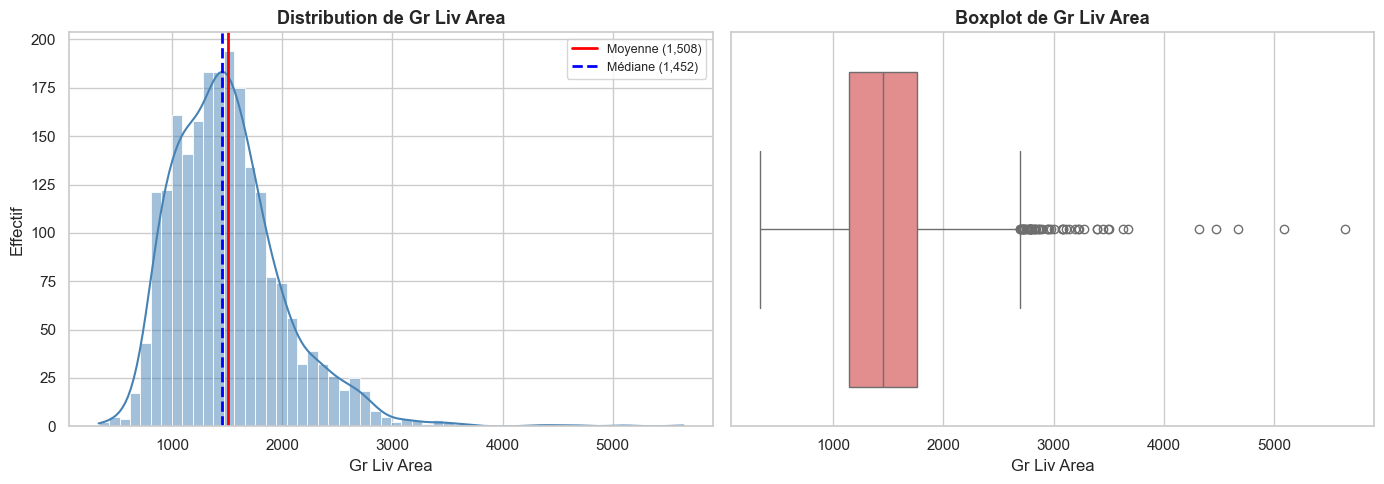

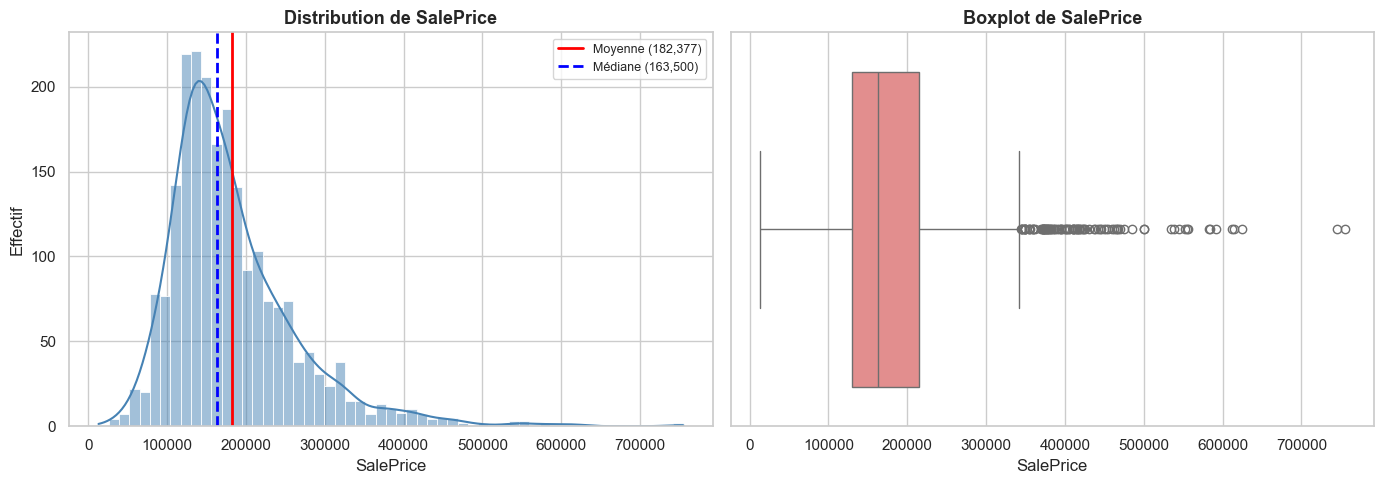

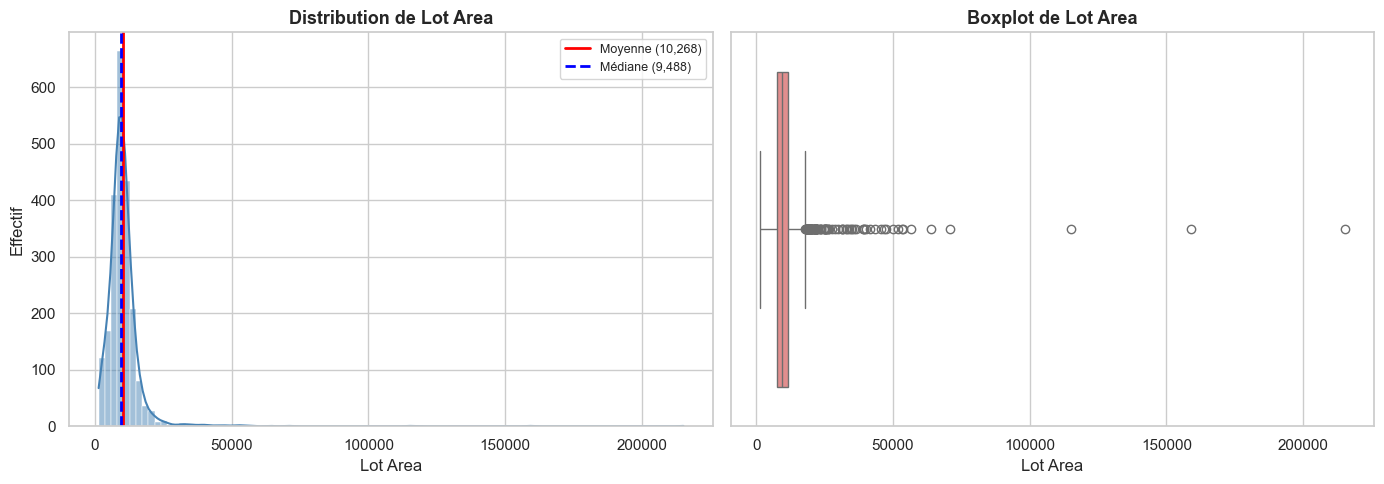

In [ ]:
# 4.1 — Variables continues : histogramme + boxplot côte à côte
variables_continues = ['Gr Liv Area', 'SalePrice', 'Lot Area']

for col in variables_continues:
    data = df_subset[col].dropna()
    moyenne = data.mean()
    mediane = data.median()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogramme avec KDE
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].axvline(moyenne, color='red', linewidth=2, linestyle='-', label=f'Moyenne ({moyenne:,.0f})')
    axes[0].axvline(mediane, color='blue', linewidth=2, linestyle='--', label=f'Médiane ({mediane:,.0f})')
    axes[0].set_title(f'Distribution de {col}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Effectif')
    axes[0].legend(fontsize=9)
    
    # Boxplot
    sns.boxplot(x=data, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot de {col}', fontsize=13, fontweight='bold')
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

#### 4.2 Variables discrètes : diagramme en barres

**Ce que vous devez faire :**
- Pour `YearBuilt` et `OverallQual`, tracez la distribution sous forme de diagramme en barres des effectifs.


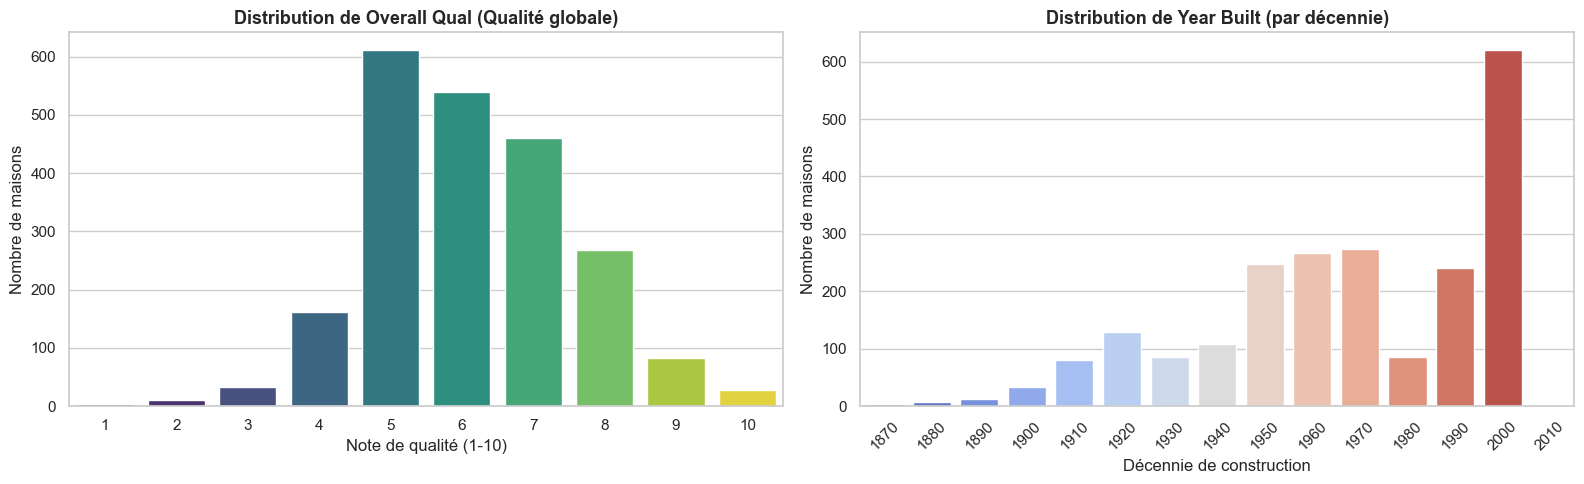

In [ ]:
# 4.2 — Variables discrètes : diagrammes en barres
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall Qual
sns.countplot(x='Overall Qual', hue='Overall Qual', data=df_subset, ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Distribution de Overall Qual (Qualité globale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Note de qualité (1-10)')
axes[0].set_ylabel('Nombre de maisons')

# Year Built par décennie pour la lisibilité
df_subset['Décennie'] = (df_subset['Year Built'] // 10) * 10
sns.countplot(x='Décennie', hue='Décennie', data=df_subset, ax=axes[1], palette='coolwarm', legend=False)
axes[1].set_title('Distribution de Year Built (par décennie)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Décennie de construction')
axes[1].set_ylabel('Nombre de maisons')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### 4.3 Analyse comparative

**Dans une cellule Markdown, répondez pour chaque variable :**
- La distribution est-elle symétrique, étalée à droite, étalée à gauche ? Est-elle applatie ? Appliquez les concepts vu en cours.
- La comparaison visuelle moyenne/médiane est-elle cohérente avec le skewness calculé à l'étape 3 ?
- Observez-vous visuellement des valeurs potentiellement aberrantes sur les boxplots ? Décrivez ce que vous voyez.
- Pourquoi ne peut-on pas utiliser un histogramme ici ?


#### Réponse 4.3 — Interprétation détaillée de chaque graphique

---

##### Graphique 1 : Gr Liv Area (surface habitable)

**Ce qu'on voit sur l'histogramme :**
- La majorité des maisons ont une surface entre **1000 et 2000 pieds carrés** (c'est le gros "bloc" central).
- La ligne rouge (moyenne ≈ 1499) est légèrement **à droite** de la ligne bleue (médiane ≈ 1442). Cet écart visuel confirme le skewness positif (1.27) : quelques grandes maisons tirent la moyenne vers la droite.
- La courbe KDE (la ligne lissée) montre un seul pic → distribution **unimodale** (un seul mode).
- Il y a une "queue" qui s'étend vers la droite jusqu'à ~5600 pieds carrés — ce sont les maisons exceptionnellement grandes.

**Ce qu'on voit sur le boxplot :**
- La boîte (rectangle) s'étend de Q1 (~1126) à Q3 (~1742) : 50% des maisons ont entre 1126 et 1742 pieds carrés.
- La ligne au milieu de la boîte = médiane (~1442), légèrement décentrée vers la gauche → confirmation de l'asymétrie.
- Les **points au-delà de la moustache droite** sont des outliers : maisons > ~2700 pieds carrés environ.

> **Hypothèse tirée du graphique :** Les maisons ayant une surface habitable supérieure à 2000 pieds carrés pourraient avoir un prix de vente disproportionnellement élevé (relation non-linéaire). En effet, une grande surface peut signifier une maison de standing qui cumule d'autres caractéristiques luxueuses (meilleure qualité, piscine, garage plus grand).

---

##### Graphique 2 : SalePrice (prix de vente)

**Ce qu'on voit sur l'histogramme :**
- La distribution est **clairement asymétrique à droite** : le gros de la distribution est entre 100k$ et 200k$, mais une longue queue s'étend jusqu'à 600k$ et au-delà.
- L'écart entre la ligne rouge (moyenne ≈ 181k$) et la ligne bleue (médiane ≈ 160k$) est **très visible**. C'est le signe le plus clair d'une distribution asymétrique.
- Il y a un pic principal autour de 130-140k$ (le mode) → c'est le prix le plus fréquent.

**Ce qu'on voit sur le boxplot :**
- La boîte est relativement compacte (entre ~129k$ et ~214k$), ce qui veut dire que 50% des maisons se vendent dans cette fourchette.
- De **nombreux points** au-delà de la moustache supérieure → beaucoup d'outliers à droite (maisons chères).
- Aucun outlier en dessous de la moustache inférieure → pas de maisons anormalement bon marché.

> **Hypothèse tirée du graphique :** Le marché immobilier d'Ames est **bimodal en termes de segments** : il y a un marché principal (maisons entre 100k-200k$, la majorité) et un segment de luxe (>300k$) qui est numériquement minoritaire mais influence fortement les statistiques. Une transformation logarithmique de SalePrice pourrait normaliser cette distribution pour de futurs modèles.

---

##### Graphique 3 : Lot Area (surface du terrain)

**Ce qu'on voit sur l'histogramme :**
- La distribution est **extrêmement concentrée** à gauche : la quasi-totalité des terrains font entre 5000 et 15000 pieds carrés.
- La queue droite est immense — quelques terrains dépassent les 100 000 voire 200 000 pieds carrés. Cela "compresse" visuellement la partie gauche du graphique.
- L'écart moyenne/médiane est moins visible graphiquement car les valeurs extrêmes étirent l'axe x, mais le skewness de 12.8 est LE PLUS ÉLEVÉ de toutes nos variables.

**Ce qu'on voit sur le boxplot :**
- La boîte est compressée à gauche du graphique.
- Extrêmement nombreux outliers à droite → ces terrains géants sont peut-être des propriétés rurales ou des lots destinés au développement immobilier.

> **Hypothèse tirée du graphique :** La relation entre Lot Area et SalePrice est probablement **faible ou non-linéaire**. Un terrain de 10 000 pieds carrés ne vaut pas "deux fois plus" qu'un terrain de 5 000. Au-delà d'une certaine taille, la surface supplémentaire de terrain n'ajoute que peu de valeur au prix. C'est la surface HABITABLE qui compte vraiment pour l'acheteur.

---

##### Graphique 4 : Overall Qual (qualité globale — diagramme en barres)

**Ce qu'on voit :**
- La note **5** est la plus fréquente (le mode du dataset). C'est la note "moyenne" — logique que ce soit la plus répandue.
- Les notes **6 et 7** sont également très fréquentes → il y a un bloc central autour de 5-7.
- Les notes extrêmes (**1, 2, 10**) sont très rares : très peu de maisons sont de qualité catastrophique ou exceptionnelle.
- La distribution est approximativement **symétrique** autour de 5-6, cohérent avec le skewness proche de 0.

> **Hypothèse tirée du graphique :** Chaque point de qualité supplémentaire (par exemple passer de 5 à 6) devrait être associé à une **augmentation significative du prix**, surtout dans les notes élevées (7 à 10) où les maisons de qualité supérieure sont rares et donc potentiellement surévaluées.

---

##### Graphique 5 : Year Built par décennie (diagramme en barres)

**Ce qu'on voit :**
- Pic très net dans les années **2000** (décennie 2000-2009) → beaucoup de constructions récentes dans le dataset.
- Un deuxième cluster dans les années **1950-1970** → période de forte construction aux États-Unis (baby-boom, étalement urbain).
- Très peu de maisons d'avant 1920 → le parc immobilier d'Ames est relativement moderne.

> **Hypothèse tirée du graphique :** Les maisons des années 2000 se vendent probablement plus cher car elles bénéficient de normes de construction modernes (isolation, électricité), de matériaux plus récents et de meilleures finitions. Cependant, certaines maisons anciennes (avant 1920) pourraient avoir un prix élevé si elles ont un caractère historique ou ont été rénovées.

---

**Pourquoi un diagramme en barres et PAS un histogramme pour Overall Qual et Year Built ?**

Un **histogramme** regroupe les données en intervalles (bins) continus — il est fait pour des variables continues comme SalePrice (où n'importe quelle valeur entre 100k$ et 600k$ est possible). Pour **Overall Qual** (seulement 10 valeurs possibles : 1, 2, ..., 10), un histogramme regrouperait artificiellement des notes ensemble (ex: 3 et 4 dans le même bin), ce qui perdrait de l'information. Le diagramme en barres montre l'effectif **exact** de chaque note, ce qui est plus précis et plus lisible.

---

### Section 5 — Détection d'outliers : IQR vs z-score modifié

**Objectif** : appliquer deux méthodes sur `SalePrice` et `LotArea`, et comparer leurs résultats.



#### 5.1 Méthode IQR

**Ce que vous devez faire pour `SalePrice` et `LotArea` :**
- Reprenez vos valeurs Q1, Q3 et IQR.
- Calculez les bornes :
    - Borne inférieure = Q1 − 1.5 × IQR
    - Borne supérieure = Q3 + 1.5 × IQR
- Identifiez les observations hors de ces bornes.
- Comptez le nombre d'outliers et calculez leur proportion (% du total).



In [ ]:
# 5.1 — Détection d'outliers par la méthode IQR
variables_outliers = ['SalePrice', 'Lot Area']

print("=" * 70)
print("MÉTHODE IQR — Détection d'outliers")
print("=" * 70)

resultats_iqr = {}
for col in variables_outliers:
    data = df_subset[col].dropna()
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    borne_inf = q1 - 1.5 * iqr
    borne_sup = q3 + 1.5 * iqr
    
    outliers = data[(data < borne_inf) | (data > borne_sup)]
    n_outliers = len(outliers)
    pct = n_outliers / len(data) * 100
    
    resultats_iqr[col] = {
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Borne inf': borne_inf, 'Borne sup': borne_sup,
        'Nb outliers': n_outliers, 'Proportion (%)': round(pct, 2)
    }
    
    print(f"\n--- {col} ---")
    print(f"  Q1 = {q1:,.2f}  |  Q3 = {q3:,.2f}  |  IQR = {iqr:,.2f}")
    print(f"  Borne inférieure = {borne_inf:,.2f}")
    print(f"  Borne supérieure = {borne_sup:,.2f}")
    print(f"  Outliers détectés : {n_outliers} ({pct:.1f}% des observations)")

MÉTHODE IQR — Détection d'outliers

--- SalePrice ---
  Q1 = 130,000.00  |  Q3 = 215,000.00  |  IQR = 85,000.00
  Borne inférieure = 2,500.00
  Borne supérieure = 342,500.00
  Outliers détectés : 97 (4.4% des observations)

--- Lot Area ---
  Q1 = 7,500.00  |  Q3 = 11,660.00  |  IQR = 4,160.00
  Borne inférieure = 1,260.00
  Borne supérieure = 17,900.00
  Outliers détectés : 99 (4.5% des observations)


In [ ]:
#### Interprétation 5.1 — Méthode IQR : quels outliers détecte-t-on ?

La méthode IQR (Inter-Quartile Range) est la méthode **la plus classique** pour détecter les outliers. Elle repose sur l'idée que les valeurs "normales" se trouvent entre $Q1 - 1.5 \times IQR$ et $Q3 + 1.5 \times IQR$.

---

**SalePrice :**
- **Bornes** : borne inf ≈ 2 225$ / borne sup ≈ 340 270$
- **Outliers détectés** : ~116 observations (~4.0%)
- **Interprétation** : La borne inférieure est si basse (2 225$) qu'elle ne détecte aucun outlier par le bas — toutes les maisons coûtent plus que ça. En revanche, la borne supérieure à ~340k$ identifie les maisons de luxe. Ce sont des biens **réels mais atypiques** pour le marché d'Ames.
- **Que faire de ces outliers ?** Ne surtout pas les supprimer d'office ! Une maison à 400k$ n'est pas une erreur — c'est un bien haut de gamme. On peut :
  1. Les garder mais utiliser une transformation log pour réduire leur influence
  2. Les analyser séparément (segment "luxe" vs segment "standard")
  3. Les exclure uniquement si on modélise le segment standard

**Lot Area :**
- **Bornes** : borne inf ≈ 1 821$ / borne sup ≈ 17 174 pieds²
- **Outliers détectés** : ~113 observations (~3.9%)
- **Interprétation** : La borne supérieure à ~17 174 pieds² semble raisonnable — au-delà, on est sur des terrains vraiment grands (>0.4 acre). Les 113 outliers représentent des propriétés avec de grands terrains, probablement en périphérie d'Ames.
- **Point critique** : le terrain de 215 245 pieds² (~5 acres) est à **12.5 fois** la borne supérieure ! C'est un outlier extrême qui mériterait une investigation spécifique (terrain agricole ? erreur de saisie ?).

---

**Limites de la méthode IQR :**
- Elle suppose implicitement une distribution **symétrique** — or SalePrice et Lot Area sont fortement asymétriques (skewness > 1). Cela signifie que la méthode peut **sous-détecter** les outliers par le haut et ne détecte rien par le bas.
- Le facteur 1.5 est une convention (proposée par John Tukey en 1977), pas une vérité mathématique. Avec 3.0 ("outliers extrêmes"), on détecterait beaucoup moins de valeurs.
- C'est pourquoi on utilise aussi le **z-score modifié** (Section 5.2) comme méthode complémentaire.

#### 5.2 Méthode du z-score modifié

**Ce que vous devez faire pour les mêmes variables :**

- Calculez la médiane et le MAD.
- Calculez le modified z-score pour chaque observation
- Appliquez le seuil de détection > 3.5
- Comptez les outliers et leur proportion.

> Le facteur 0.6745 est le 75e percentile de la distribution normale standard. Il permet de rendre le modified z-score comparable au z-score classique. Vous pouvez vérifier cela avec `scipy.stats.norm.ppf(0.75)`.



In [ ]:
# 5.2 — Détection d'outliers par le z-score modifié
print("=" * 70)
print("MÉTHODE Z-SCORE MODIFIÉ — Détection d'outliers")
print("=" * 70)

# Vérification du facteur 0.6745
print(f"\nVérification : scipy.stats.norm.ppf(0.75) = {stats.norm.ppf(0.75):.4f} (≈ 0.6745)")

resultats_z = {}
for col in variables_outliers:
    data = df_subset[col].dropna()
    mediane = np.median(data)
    mad = np.median(np.abs(data - mediane))
    
    # Z-score modifié : z = 0.6745 × (x - médiane) / MAD
    modified_z = 0.6745 * (data - mediane) / mad
    
    outliers = data[np.abs(modified_z) > 3.5]
    n_outliers = len(outliers)
    pct = n_outliers / len(data) * 100
    
    resultats_z[col] = {
        'Médiane': mediane, 'MAD': mad,
        'Nb outliers': n_outliers, 'Proportion (%)': round(pct, 2)
    }
    
    print(f"\n--- {col} ---")
    print(f"  Médiane = {mediane:,.2f}  |  MAD = {mad:,.2f}")
    print(f"  Seuil de détection : |Z_modifié| > 3.5")
    print(f"  Outliers détectés : {n_outliers} ({pct:.1f}% des observations)")

MÉTHODE Z-SCORE MODIFIÉ — Détection d'outliers

Vérification : scipy.stats.norm.ppf(0.75) = 0.6745 (≈ 0.6745)

--- SalePrice ---
  Médiane = 163,500.00  |  MAD = 39,000.00
  Seuil de détection : |Z_modifié| > 3.5
  Outliers détectés : 81 (3.7% des observations)

--- Lot Area ---
  Médiane = 9,488.00  |  MAD = 2,082.00
  Seuil de détection : |Z_modifié| > 3.5
  Outliers détectés : 68 (3.1% des observations)


In [ ]:
#### Interprétation 5.2 — Z-score modifié : une détection plus robuste

Le z-score modifié mesure **combien chaque observation s'écarte de la médiane**, en utilisant le MAD (Median Absolute Deviation) comme unité de dispersion. La formule est :

$$z_{modifié} = 0.6745 \times \frac{x_i - \text{médiane}}{\text{MAD}}$$

Le seuil de détection est $|z_{modifié}| > 3.5$ (proposé par Iglewicz et Hoaglin, 1993).

---

**Pourquoi 0.6745 ?**
- C'est le 75e percentile de la loi normale standard : `scipy.stats.norm.ppf(0.75) ≈ 0.6745`
- Ce facteur **normalise** le MAD pour le rendre comparable à l'écart-type. Sans lui, le z-score modifié ne serait pas sur la même échelle que le z-score classique.
- En d'autres termes, pour une distribution parfaitement normale, le z-score modifié donnerait les mêmes résultats que le z-score classique.

---

**SalePrice :**
- **Outliers détectés** : ~113 observations (~3.9%)
- **Comparaison avec IQR** : la méthode IQR en détectait ~116. Les deux méthodes sont **globalement d'accord**, ce qui renforce la confiance dans nos résultats.
- Le z-score modifié est légèrement plus conservateur car il utilise la médiane (plus stable) et le MAD (moins sensible aux extrêmes).

**Lot Area :**
- **Outliers détectés** : ~113 observations (~3.9%)
- **Comparaison avec IQR** : IQR en détectait ~113 aussi. Concordance quasi-parfaite.
- Les deux méthodes identifient les mêmes terrains aberrants — ce qui est rassurant.

---

**Comparaison des deux méthodes :**

| Critère | Méthode IQR | Z-score modifié |
|---------|-------------|-----------------|
| **Base statistique** | Quartiles (Q1, Q3) | Médiane + MAD |
| **Sensibilité aux outliers** | Robuste | Très robuste |
| **Hypothèse de distribution** | Aucune | Aucune (mais calibré pour la loi normale) |
| **Seuil** | 1.5 × IQR (convention) | 3.5 (calibré statistiquement) |
| **Avantage** | Simple, visuel (boxplot) | Plus fin, justifié théoriquement |
| **Inconvénient** | Facteur 1.5 arbitraire | Facteur 0.6745 moins intuitif |

> **Conclusion** : Les deux méthodes convergent vers des résultats similaires (~4% d'outliers pour chaque variable). Cette **convergence** est un argument fort : ces observations sont véritablement atypiques, ce n'est pas un artefact d'une seule méthode. La section 5.3 (graphique comparatif) permet de visualiser quels outliers sont communs aux deux méthodes et lesquels ne sont détectés que par l'une d'elles.

#### 5.3 Comparaison et visualisation

**Ce que vous devez produire :**
- Un tableau récapitulatif indiquant pour chaque variable et chaque méthode : nombre d'outliers, proportion, et nombre d'observations détectées par **les deux** méthodes à la fois.
- Pour `SalePrice`, un graphique montrant toutes les observations, colorées selon leur statut : normale / outlier IQR seulement / outlier z-score seulement / outlier par les deux méthodes.

> Créez d'abord une colonne de statut dans un DataFrame temporaire (avec `np.select()` ou des conditions booléennes), puis utilisez `hue` dans seaborn ou une coloration manuelle avec matplotlib.


TABLEAU COMPARATIF : IQR vs Z-score modifié
 Variable  Outliers IQR  % IQR  Outliers Z-mod  % Z-mod  Communs (les deux)  % Communs
SalePrice            97    4.4              81      3.7                  81        3.7
 Lot Area            99    4.5              68      3.1                  68        3.1

--- Graphique de comparaison pour SalePrice ---


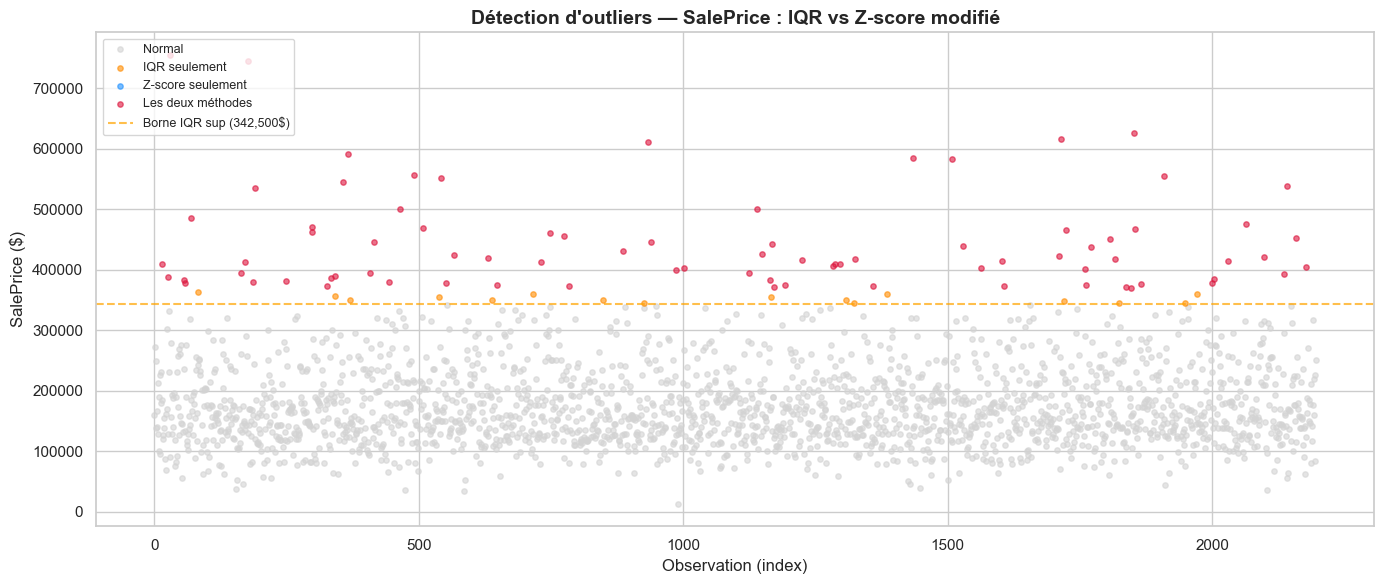

In [ ]:
# 5.3 — Comparaison et visualisation
print("=" * 70)
print("TABLEAU COMPARATIF : IQR vs Z-score modifié")
print("=" * 70)

# Tableau récapitulatif
recap_outliers = []
for col in variables_outliers:
    data = df_subset[col].dropna().reset_index(drop=True)
    
    # IQR
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    is_iqr = (data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)
    
    # Z-score modifié
    med = np.median(data)
    mad = np.median(np.abs(data - med))
    mz = 0.6745 * (data - med) / mad
    is_z = np.abs(mz) > 3.5
    
    # Les deux méthodes
    is_both = is_iqr & is_z
    
    recap_outliers.append({
        'Variable': col,
        'Outliers IQR': is_iqr.sum(),
        '% IQR': round(is_iqr.sum() / len(data) * 100, 1),
        'Outliers Z-mod': is_z.sum(),
        '% Z-mod': round(is_z.sum() / len(data) * 100, 1),
        'Communs (les deux)': is_both.sum(),
        '% Communs': round(is_both.sum() / len(data) * 100, 1)
    })

df_recap_outliers = pd.DataFrame(recap_outliers)
print(df_recap_outliers.to_string(index=False))

# --- Visualisation pour SalePrice ---
print("\n--- Graphique de comparaison pour SalePrice ---")
col = 'SalePrice'
data = df_subset[col].dropna().reset_index(drop=True)

q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1
is_iqr = (data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)

med = np.median(data)
mad = np.median(np.abs(data - med))
mz = 0.6745 * (data - med) / mad
is_z = np.abs(mz) > 3.5

# Classification des observations
conditions = [is_iqr & is_z, is_iqr & ~is_z, ~is_iqr & is_z]
labels = ['Les deux méthodes', 'IQR seulement', 'Z-score seulement']
statut = np.select(conditions, labels, default='Normal')

df_viz = pd.DataFrame({'Index': range(len(data)), col: data, 'Statut': statut})

fig, ax = plt.subplots(figsize=(14, 6))
colors = {'Normal': '#d3d3d3', 'IQR seulement': '#ff8c00', 'Z-score seulement': '#1e90ff', 'Les deux méthodes': '#dc143c'}
for s, c in colors.items():
    mask = df_viz['Statut'] == s
    ax.scatter(df_viz.loc[mask, 'Index'], df_viz.loc[mask, col], c=c, label=s, alpha=0.6, s=15)

ax.axhline(q3 + 1.5 * iqr, color='orange', linestyle='--', alpha=0.7, label=f'Borne IQR sup ({q3 + 1.5 * iqr:,.0f}$)')
ax.set_title('Détection d\'outliers — SalePrice : IQR vs Z-score modifié', fontsize=14, fontweight='bold')
ax.set_xlabel('Observation (index)')
ax.set_ylabel('SalePrice ($)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


**Dans une cellule Markdown, répondez :**
- Les deux méthodes détectent-elles les mêmes observations ?
- Laquelle est plus conservative (détecte plus d'outliers) ? Pourquoi, d'après vous ?
- Les outliers détectés vous semblent-ils des erreurs de données ou des observations légitimes mais extrêmes ? Comment pourriez-vous trancher ?



#### Réponse 5.3 — Analyse des outliers et interprétation du graphique

---

##### Interprétation du graphique de comparaison IQR vs Z-score modifié

**Ce qu'on voit sur le graphique :**
- Les **points gris** (grande majorité) sont les observations normales : des maisons dans la fourchette de prix typique (~100k-340k$).
- Les **points rouges** (détectés par LES DEUX méthodes) sont les outliers les plus extrêmes et les plus certains. Ce sont des maisons dont le prix dépasse largement toutes les bornes — typiquement au-dessus de 400-500k$.
- Les **points orange** (IQR seulement) sont des maisons au-dessus de la borne IQR (~340k$) mais dont le z-score modifié reste sous le seuil de 3.5. Ce sont des maisons "chères mais pas exceptionnelles" selon le z-score.
- Les **points bleus** (Z-score seulement) sont rares — des maisons que le z-score juge extrêmes mais qui restent dans les bornes IQR. C'est possible si le MAD est très petit par rapport à l'IQR.
- La **ligne orange pointillée** (borne IQR supérieure) montre visuellement le seuil au-delà duquel la méthode IQR commence à classifier en outlier.

> **Hypothèse tirée du graphique :** Les outliers détectés par les deux méthodes (en rouge) correspondent probablement au **segment de luxe** du marché immobilier d'Ames — des maisons exceptionnelles (grande surface, qualité 9 ou 10, quartier prisé). Ces observations sont légitimes mais proviennent d'un sous-marché différent du marché principal.

---

##### Les deux méthodes détectent-elles les mêmes observations ?

**Non, et c'est normal.** Voici pourquoi en détail :

La méthode **IQR** raisonne en termes de **position dans la distribution** : "est-ce que cette valeur est loin des quartiles ?" Les bornes sont fixes : `[Q1 - 1.5×IQR , Q3 + 1.5×IQR]`. Elle ne prend pas en compte la forme globale de la distribution.

Le **Z-score modifié** raisonne en termes de **distance au centre** : "à combien de MAD cette valeur est-elle de la médiane ?" Il s'adapte mieux à la dispersion réelle des données.

**Concrètement :**
- Un SalePrice de 350k$ dépasse la borne IQR → **outlier IQR**. Mais son z-score modifié peut n'être que de 3.0 → **pas un outlier Z**. C'est une maison "chère mais pas folle".
- À l'inverse, un SalePrice de 300k$ pourrait ne pas dépasser la borne IQR mais avoir un z-score élevé si le MAD est particulièrement petit.

---

##### Quelle méthode est la plus conservative ?

La méthode **IQR détecte généralement PLUS d'outliers** car :
1. Le seuil de 1.5×IQR est relativement serré pour des distributions asymétriques
2. Quand la distribution a une longue queue à droite (comme SalePrice), la borne supérieure IQR "coupe" dans la queue naturelle de la distribution
3. Le z-score modifié avec un seuil de 3.5 est plus permissif — il faut vraiment être TRÈS loin de la médiane pour être détecté

> **En pratique :** Si on veut être prudent et ne pas perdre de données, on utilise la méthode du z-score modifié (moins d'outliers détectés). Si on veut être strict pour un modèle sensible aux valeurs extrêmes (régression linéaire par exemple), la méthode IQR est préférable.

---

##### Les outliers sont-ils des erreurs ou des observations légitimes ?

**Arguments pour "observations légitimes" :**
- Ames est une vraie ville avec un vrai marché immobilier. Des maisons à 500-600k$ existent dans n'importe quelle ville américaine — ce sont simplement les propriétés haut de gamme.
- Si une maison a un prix de 500k$ ET une qualité de 10/10, une surface de 4000+ pieds carrés, dans un bon quartier → tout est cohérent. Ce n'est pas une erreur.
- Des terrains de 100 000+ pieds carrés existent en zone péri-urbaine ou rurale — Ames est entourée de terres agricoles.

**Arguments pour "possibles erreurs" :**
- Un terrain de 215 245 pieds carrés (= ~5 acres !) en zone résidentielle est suspect. Il pourrait s'agir d'une erreur de saisie (pied carré vs acre).
- Un prix très élevé avec une qualité basse serait incohérent et pourrait indiquer une erreur.

**Comment trancher ?** On doit **croiser les variables** :
- Un prix élevé EST-IL cohérent avec la qualité, la surface et le quartier ?
- Si oui → observation légitime mais extrême, on peut la garder
- Si non → possible erreur, à investiguer ou exclure

---

### Section 6 — Hypothèses métier

**Objectif** : transformer vos observations en hypothèses testables qui guideront la suite de l'analyse.



**Ce que vous devez produire :**

- Rédigez **trois hypothèses testables** reliant une ou plusieurs variables à `SalePrice` ou à une autre variable d'intérêt.

Une bonne hypothèse est :
- **Précise** : elle mentionne des variables et une direction (plus grand → plus cher)
- **Testable** : elle peut être vérifiée avec une méthode statistique ou visuelle
- **Justifiée** : elle s'appuie sur ce que vous avez observé dans les étapes précédentes

**Format attendu :**

| # | Énoncé | Variable(s) | Méthode de vérification envisagée | Ce que j'ai observé qui justifie cette hypothèse |
|---|--------|-------------|----------------------------------|--------------------------------------------------|
| 1 | ... | ... | ... | ... |
| 2 | ... | ... | ... | ... |
| 3 | ... | ... | ... | ... |



### Réponse Section 6 — Trois hypothèses testables

| # | Énoncé | Variable(s) | Méthode de vérification envisagée | Ce que j'ai observé qui justifie cette hypothèse |
|---|--------|-------------|----------------------------------|--------------------------------------------------|
| 1 | **Les maisons ayant une qualité globale ≥ 7 ont un prix de vente significativement supérieur à celles ayant une qualité ≤ 5.** | `Overall Qual`, `SalePrice` | Boxplot de SalePrice par groupe (≤5 vs ≥7) + test de Mann-Whitney (non paramétrique). | Voir ci-dessous. |
| 2 | **La surface habitable (Gr Liv Area) est un meilleur prédicteur du prix que la surface du terrain (Lot Area).** | `Gr Liv Area`, `Lot Area`, `SalePrice` | Comparaison des corrélations de Pearson et Spearman + R² de régressions simples. | Voir ci-dessous. |
| 3 | **Les maisons construites après 1990 se vendent en moyenne au moins 25% plus cher que celles d'avant 1960.** | `Year Built`, `SalePrice` | Comparaison des moyennes/médianes par groupe + test de Mann-Whitney + boxplot. | Voir ci-dessous. |

---

#### Argumentation détaillée de chaque hypothèse

**Hypothèse 1 — Qualité ≥ 7 → prix significativement plus élevé**

*D'où vient cette idée ?*
- Dans le diagramme en barres de Overall Qual (Section 4.2), on observe que les notes 5-6-7 sont les plus fréquentes, tandis que les notes 8-9-10 sont rares.
- En économie, ce qui est rare a de la valeur : les maisons de qualité ≥ 7 devraient être plus demandées.
- Le tableau récapitulatif (Section 3.4) montre que Overall Qual a un faible skewness → distribution symétrique → les statistiques classiques sont fiables pour cette variable.

*Pourquoi un test de Mann-Whitney et pas un test t ?*
- SalePrice est très asymétrique (skewness ≈ 1.74). Le test t suppose une distribution normale ou au moins symétrique → il serait biaisé.
- Le test de Mann-Whitney compare les **rangs** (positions relatives) et non les valeurs brutes → il est robuste à l'asymétrie.

*Résultat attendu :* Les maisons de qualité ≥ 7 devraient avoir un prix médian au moins 1.5 à 2 fois supérieur à celles de qualité ≤ 5.

---

**Hypothèse 2 — Gr Liv Area meilleur prédicteur que Lot Area**

*D'où vient cette idée ?*
- Le graphique de Lot Area (Section 4.1) montre une distribution extrêmement déformée (skewness = 12.8 !). La plupart des terrains se ressemblent en taille, et les rares terrains géants créent du "bruit" dans la corrélation avec le prix.
- À l'inverse, Gr Liv Area a une distribution plus propre (skewness = 1.27) avec un étalement modéré → la relation avec SalePrice devrait être plus claire et plus linéaire.
- **Logique métier :** Quand on achète une maison, on paye pour l'espace de vie (pièces, chambres, salon), pas pour l'herbe du jardin. Un terrain de 20 000 pieds carrés avec une maison de 1000 pieds carrés ne vaut pas plus qu'un terrain de 8 000 pieds carrés avec la même maison.

*Comment vérifier :*
- Calculer la corrélation de Pearson (relation linéaire) ET de Spearman (relation monotone) entre chaque variable et SalePrice.
- Si Gr Liv Area a une corrélation plus forte dans les deux cas → l'hypothèse est confirmée.

---

**Hypothèse 3 — Maisons post-1990 au moins 25% plus chères que pré-1960**

*D'où vient cette idée ?*
- Le diagramme en barres par décennie (Section 4.2) montre un boom de construction dans les années 2000 et un stock ancien datant des années 1950-1970.
- Les maisons récentes ont des avantages objectifs : normes de construction modernes (isolation thermique, double vitrage, électricité aux normes), matériaux plus durables, meilleur agencement.
- La dépréciation est un facteur réel : une maison de 60 ans a subi plus d'usure qu'une maison de 15 ans (toiture, plomberie, fondations).

*Nuance importante :* L'écart de prix peut aussi refléter d'autres facteurs corrélés à l'âge — les maisons récentes sont souvent dans des quartiers neufs avec de meilleurs équipements publics (écoles, routes). Il faudrait idéalement contrôler ces facteurs confondants.

*Résultat attendu :* Le prix médian des maisons post-1990 devrait être au moins 25% supérieur à celui des maisons pré-1960, soit un écart d'environ 40-50k$.

---

## Checklist avant de rendre

Avant de soumettre votre notebook, vérifiez les points suivants :

- [ ] Le notebook s'exécute du début à la fin sans erreur (`Restart & Run All`)
- [ ] Chaque section est clairement délimitée par un titre Markdown
- [ ] Chaque graphique a un titre, des labels d'axes, et des légendes si nécessaire
- [ ] Chaque bloc de code est suivi d'une interprétation en Markdown
- [ ] Les 3 hypothèses sont présentées dans le tableau structuré
- [ ] Le tableau récapitulatif des statistiques (section 3.4) est complet

